<a href="https://colab.research.google.com/github/MH-Tuhin83/G-Colab-AML/blob/main/Regression_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import math
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")


In [7]:
from google.colab import files
uploaded = files.upload()

Saving rt_iot2022_regression_ready_50_features.csv to rt_iot2022_regression_ready_50_features.csv


In [8]:
DATA_PATH = "/content/rt_iot2022_regression_ready_50_features.csv"
df = pd.read_csv(DATA_PATH)

In [9]:
DATA_PATH = "/content/rt_iot2022_regression_ready_50_features.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)
print(df.head())
print(df.columns.tolist())

(123117, 51)
   id.orig_p  id.resp_p proto service  fwd_pkts_tot  bwd_pkts_tot  \
0      38667       1883   tcp    mqtt             9             5   
1      51143       1883   tcp    mqtt             9             5   
2      44761       1883   tcp    mqtt             9             5   
3      60893       1883   tcp    mqtt             9             5   
4      51087       1883   tcp    mqtt             9             5   

   fwd_data_pkts_tot  bwd_data_pkts_tot  fwd_pkts_per_sec  bwd_pkts_per_sec  \
0                  3                  3          0.281148          0.156193   
1                  3                  3          0.282277          0.156821   
2                  3                  3          0.280164          0.155647   
3                  3                  3          0.281593          0.156440   
4                  3                  3          0.282111          0.156728   

   ...  flow_pkts_payload.avg  flow_pkts_payload.std  fwd_iat.min  \
0  ...               7.71428

In [10]:
print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nTarget summary:")
print(df["flow_duration"].describe())

Missing values:
id.orig_p              0
id.resp_p              0
proto                  0
service                0
fwd_pkts_tot           0
bwd_pkts_tot           0
fwd_data_pkts_tot      0
bwd_data_pkts_tot      0
fwd_pkts_per_sec       0
bwd_pkts_per_sec       0
flow_pkts_per_sec      0
down_up_ratio          0
fwd_header_size_tot    0
fwd_header_size_min    0
fwd_header_size_max    0
bwd_header_size_tot    0
bwd_header_size_min    0
bwd_header_size_max    0
flow_FIN_flag_count    0
flow_SYN_flag_count    0
dtype: int64

Target summary:
count    123117.000000
mean          3.809566
std         130.005408
min           0.000000
25%           0.000001
50%           0.000004
75%           0.000005
max       21728.335580
Name: flow_duration, dtype: float64


In [11]:
TARGET = "flow_duration"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (123117, 50)
y shape: (123117,)


In [13]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object"]).columns.tolist()
print("Categorical columns:", categorical_features)
print("Number of numeric columns:", len(numeric_features))

Categorical columns: ['proto', 'service']
Number of numeric columns: 48


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (98493, 50)
Test shape: (24624, 50)


In [15]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

scaled_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

unscaled_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]),
            numeric_features
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features
        )
    ]
)

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

models = {
    "Linear Regression": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", LinearRegression())
    ]),

    "Decision Tree Regressor": Pipeline([
        ("preprocessor", unscaled_preprocessor),
        ("model", DecisionTreeRegressor(random_state=42, max_depth=15))
    ]),

    "Random Forest Regressor": Pipeline([
        ("preprocessor", unscaled_preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1,
            max_depth=20
        ))
    ]),

    "KNN Regressor": Pipeline([
        ("preprocessor", scaled_preprocessor),
        ("model", KNeighborsRegressor(n_neighbors=5, n_jobs=-1))
    ])
}

In [17]:
import math
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []
trained_models = {}

for name, pipeline in models.items():
    print(f"\nTraining {name}...")
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = math.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2_Score": r2
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values(by="R2_Score", ascending=False)
print("\nFinal Results:")
print(results_df)


Training Linear Regression...

Training Decision Tree Regressor...

Training Random Forest Regressor...

Training KNN Regressor...

Final Results:
                     Model       MAE      RMSE  R2_Score
1  Decision Tree Regressor  0.020577  0.768873  0.998085
2  Random Forest Regressor  0.029338  1.407441  0.993582
0        Linear Regression  0.204294  4.400191  0.937266
3            KNN Regressor  0.271042  7.080595  0.837558


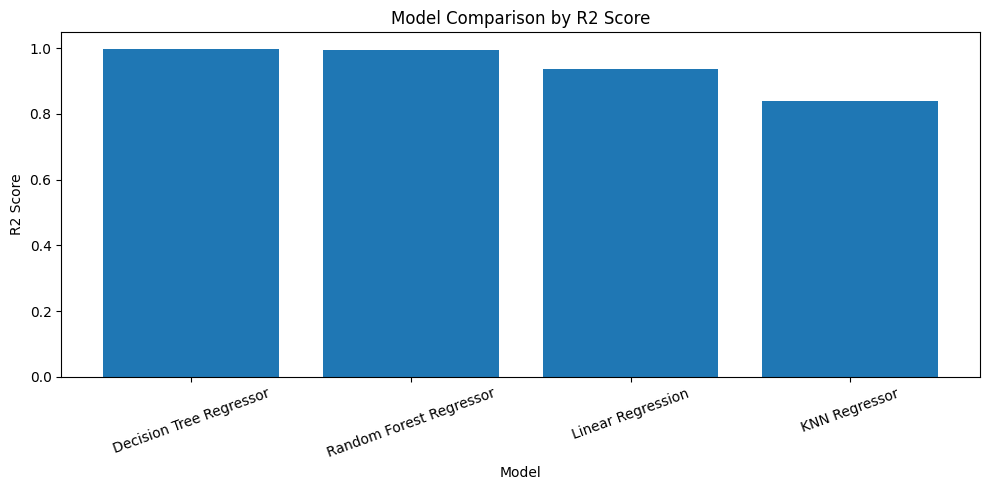

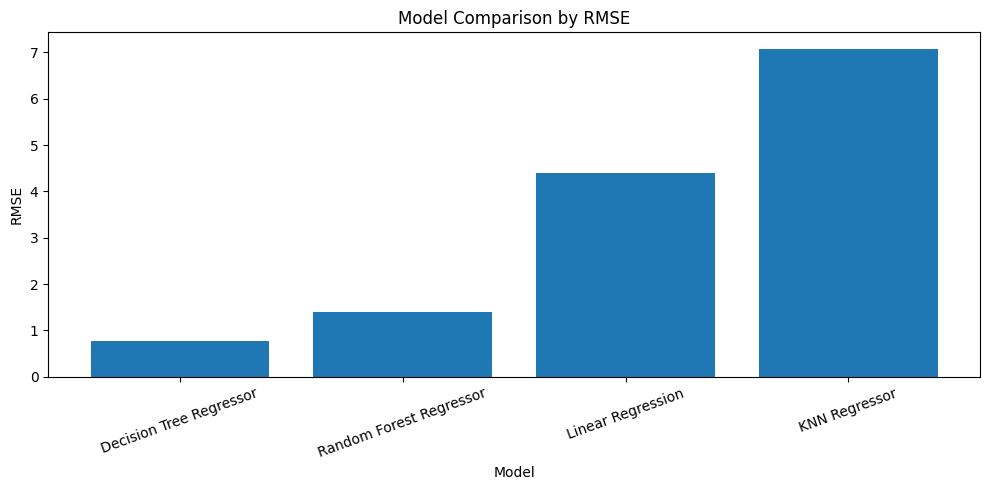

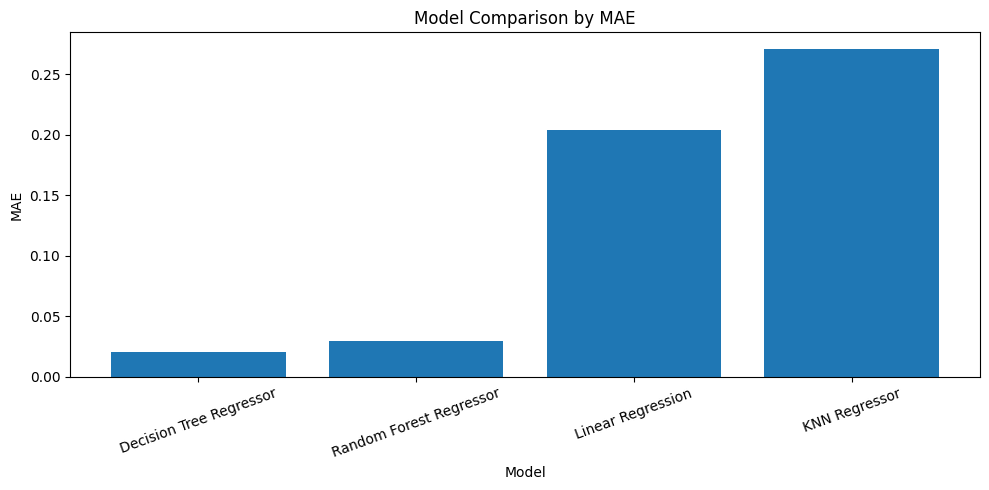

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["R2_Score"])
plt.title("Model Comparison by R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [19]:
import os
import joblib

save_dir = "/content/saved_models"
os.makedirs(save_dir, exist_ok=True)

for name, model in trained_models.items():
    file_name = name.lower().replace(" ", "_") + ".joblib"
    joblib.dump(model, os.path.join(save_dir, file_name))

print("Models saved successfully.")

Models saved successfully.


In [20]:
X2 = df.drop(columns=["flow_duration", "fwd_iat.tot"])
y2 = df["flow_duration"]

cat2 = X2.select_dtypes(include=["object"]).columns.tolist()
num2 = X2.select_dtypes(exclude=["object"]).columns.tolist()

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import math

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)

pre2 = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median"))
        ]), num2),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat2)
    ]
)

rf2 = Pipeline([
    ("preprocessor", pre2),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        max_depth=20
    ))
])

rf2.fit(X2_train, y2_train)
y2_pred = rf2.predict(X2_test)

mae2 = mean_absolute_error(y2_test, y2_pred)
rmse2 = math.sqrt(mean_squared_error(y2_test, y2_pred))
r22 = r2_score(y2_test, y2_pred)

print("Random Forest without fwd_iat.tot")
print("MAE:", mae2)
print("RMSE:", rmse2)
print("R2:", r22)

Random Forest without fwd_iat.tot
MAE: 0.2877980053602932
RMSE: 12.456923372249705
R2: 0.4972158947550519


In [21]:
output_dir = "/content/final_outputs"
os.makedirs(output_dir, exist_ok=True)

print("Output folder created:", output_dir)

Output folder created: /content/final_outputs


In [22]:
results_df.to_csv(f"{output_dir}/model_results.csv", index=False)
print("Saved: model_results.csv")

Saved: model_results.csv


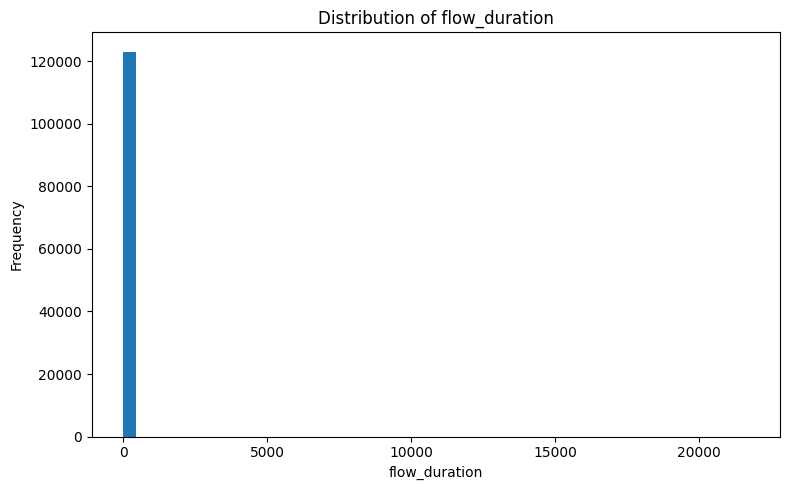

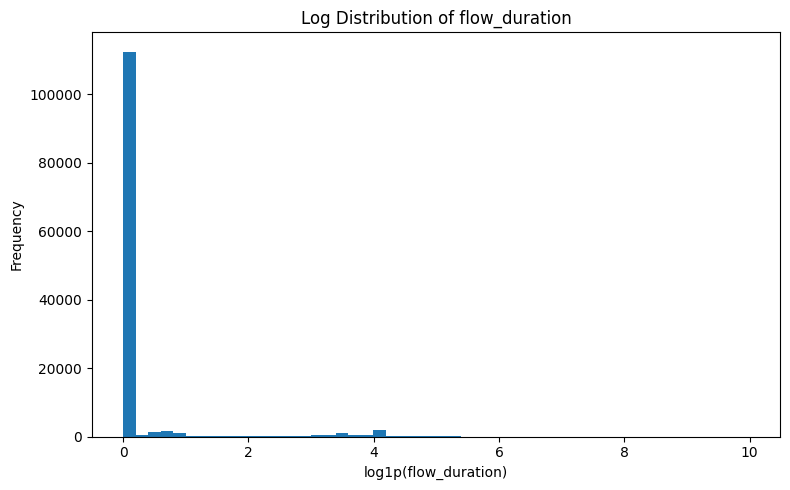

In [23]:
plt.figure(figsize=(8, 5))
plt.hist(df["flow_duration"], bins=50)
plt.title("Distribution of flow_duration")
plt.xlabel("flow_duration")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{output_dir}/target_distribution.png")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(np.log1p(df["flow_duration"]), bins=50)
plt.title("Log Distribution of flow_duration")
plt.xlabel("log1p(flow_duration)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(f"{output_dir}/log_target_distribution.png")
plt.show()

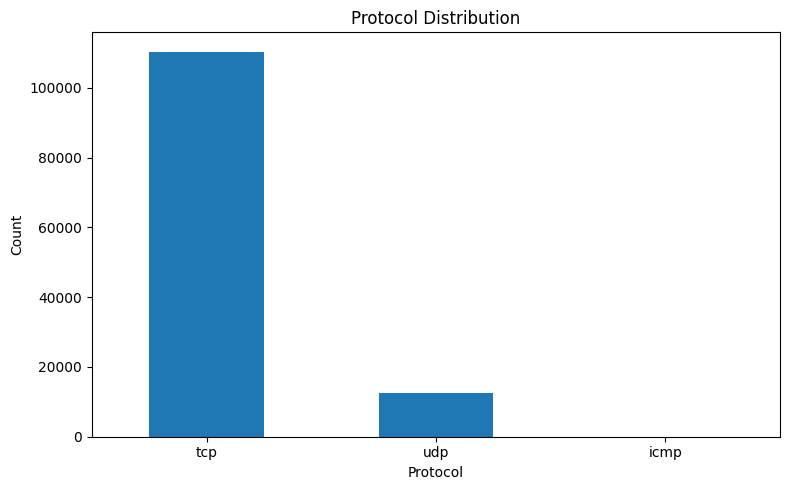

In [24]:
if "proto" in df.columns:
    proto_counts = df["proto"].value_counts()
    proto_counts.to_csv(f"{output_dir}/proto_counts.csv")

    plt.figure(figsize=(8, 5))
    proto_counts.plot(kind="bar")
    plt.title("Protocol Distribution")
    plt.xlabel("Protocol")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/protocol_distribution.png")
    plt.show()

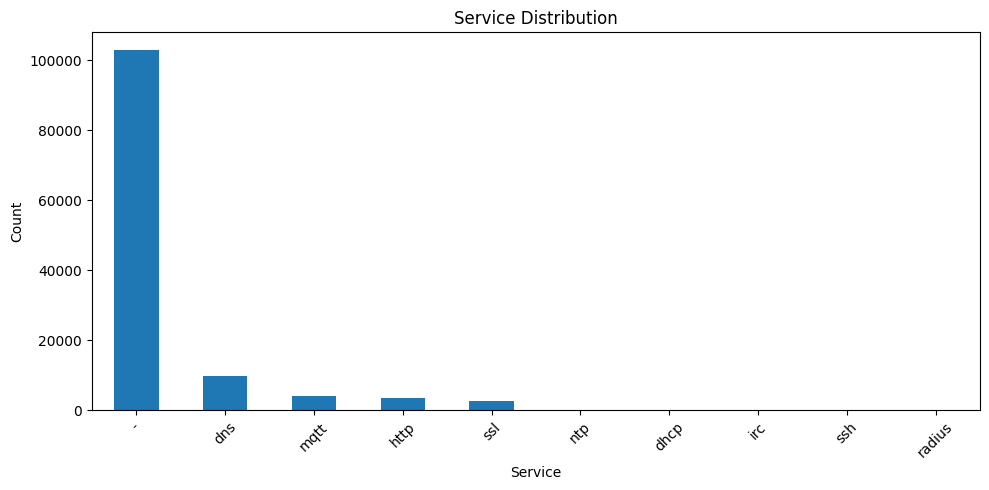

In [25]:
if "service" in df.columns:
    service_counts = df["service"].value_counts()
    service_counts.to_csv(f"{output_dir}/service_counts.csv")

    plt.figure(figsize=(10, 5))
    service_counts.plot(kind="bar")
    plt.title("Service Distribution")
    plt.xlabel("Service")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(f"{output_dir}/service_distribution.png")
    plt.show()


Top 10 correlated numeric features with flow_duration:
                Feature  Correlation
0           fwd_iat.tot     0.999719
1     fwd_data_pkts_tot     0.754355
2          fwd_pkts_tot     0.741707
3  fwd_pkts_payload.tot     0.532682
4   fwd_header_size_tot     0.472366
5    fwd_PSH_flag_count     0.404517
6    bwd_PSH_flag_count     0.290758
7           bwd_iat.max     0.169711
8           fwd_iat.avg     0.146800
9   flow_ACK_flag_count     0.137856


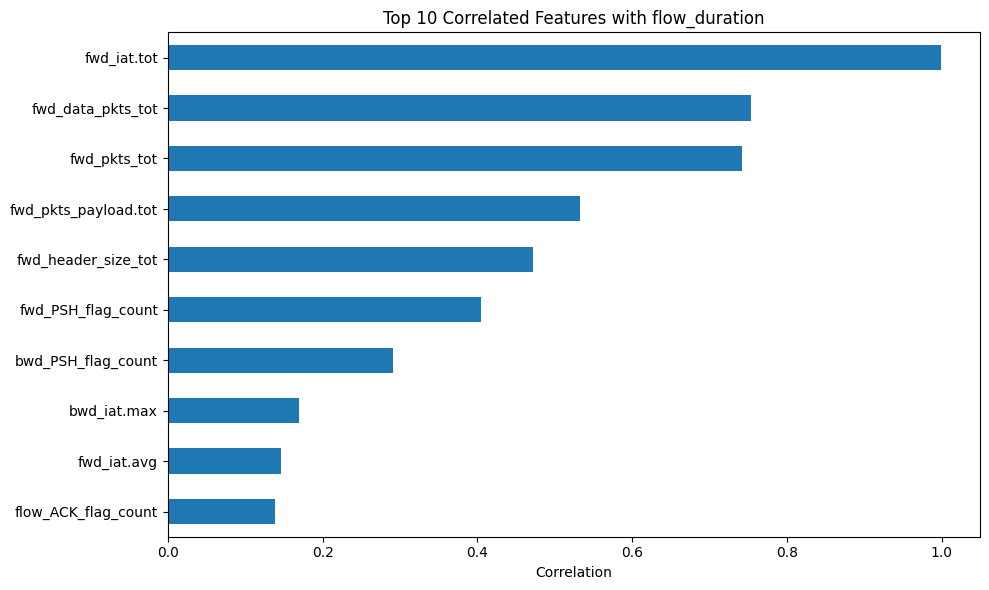

In [26]:
numeric_df = df.select_dtypes(include=[np.number])

corr_with_target = numeric_df.corr()["flow_duration"].drop("flow_duration").sort_values(
    key=np.abs, ascending=False
)
corr_df = corr_with_target.reset_index()
corr_df.columns = ["Feature", "Correlation"]
corr_df.to_csv(f"{output_dir}/top_correlations.csv", index=False)

print("\nTop 10 correlated numeric features with flow_duration:")
print(corr_df.head(10))

plt.figure(figsize=(10, 6))
corr_with_target.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Correlated Features with flow_duration")
plt.xlabel("Correlation")
plt.tight_layout()
plt.savefig(f"{output_dir}/top_correlated_features.png")
plt.show()

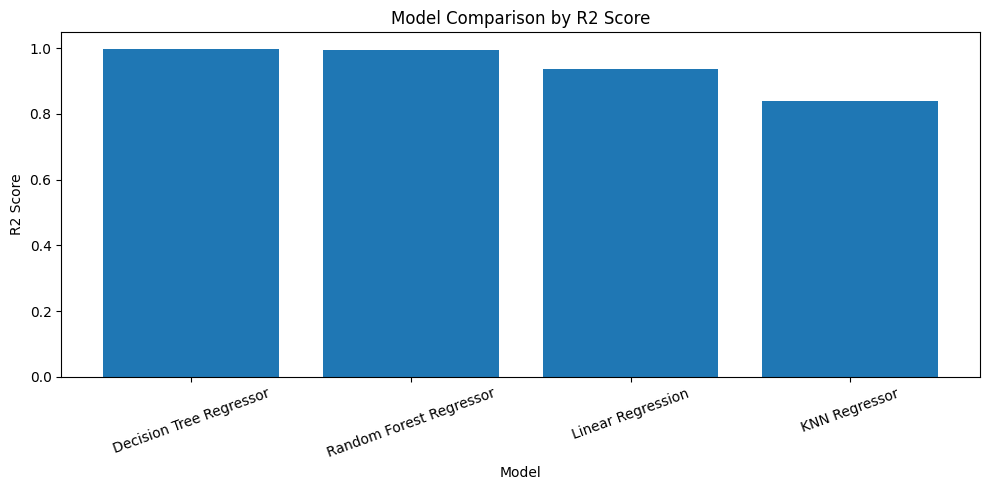

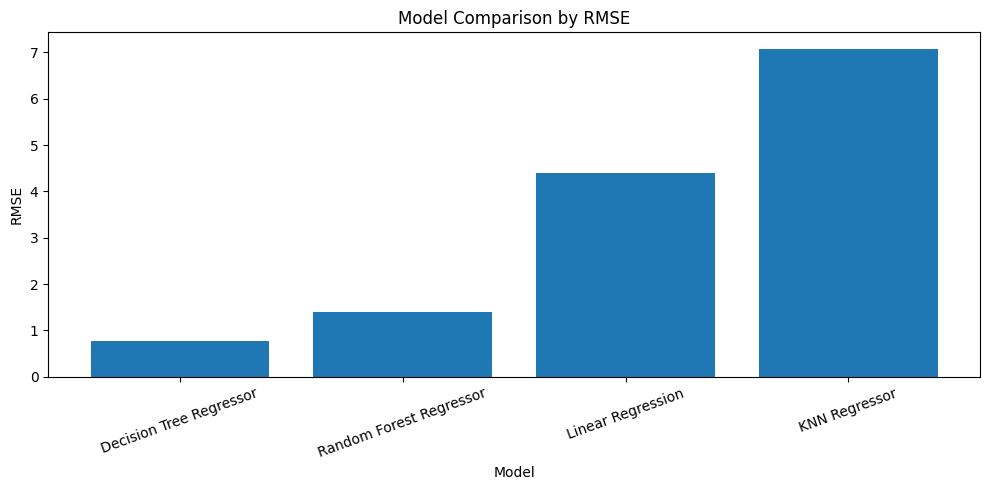

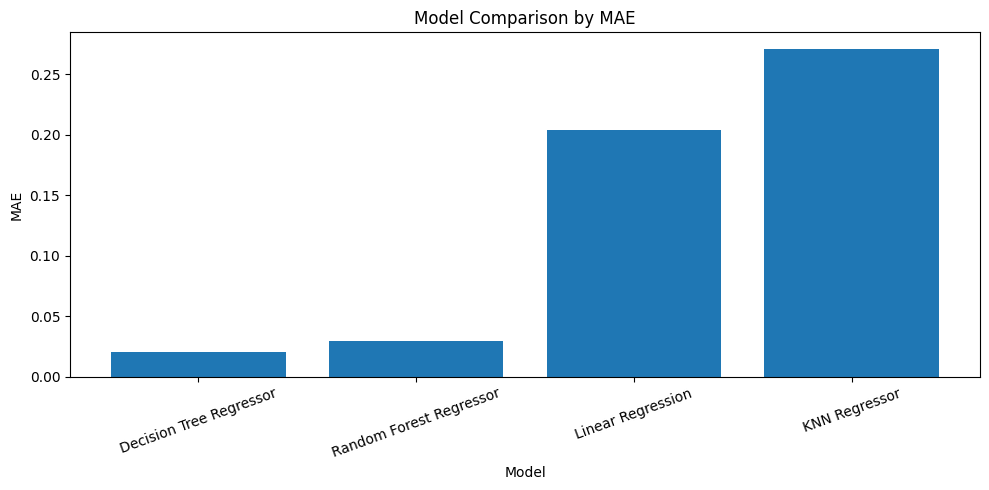

In [27]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["R2_Score"])
plt.title("Model Comparison by R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{output_dir}/model_comparison_r2.png")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("Model Comparison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{output_dir}/model_comparison_rmse.png")
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("Model Comparison by MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(f"{output_dir}/model_comparison_mae.png")
plt.show()


Best model: Decision Tree Regressor
Saved: actual_vs_predicted.csv

Sample actual vs predicted:
       Actual  Predicted
0    0.000001   0.000024
1    0.000004   0.000024
2    0.000002   0.000024
3   62.052435  62.046643
4    0.000000   0.000024
5    0.000005   0.000024
6    0.000005   0.000024
7    0.000004   0.000024
8    0.000009   0.000024
9    0.021367   0.040004
10   0.000004   0.000024
11   0.000002   0.000024
12   0.000004   0.000024
13   0.000000   0.000024
14   0.000001   0.000024
15   0.045634   0.040004
16   0.026556   0.040004
17   0.000001   0.000024
18   0.000002   0.000024
19   0.000001   0.000024


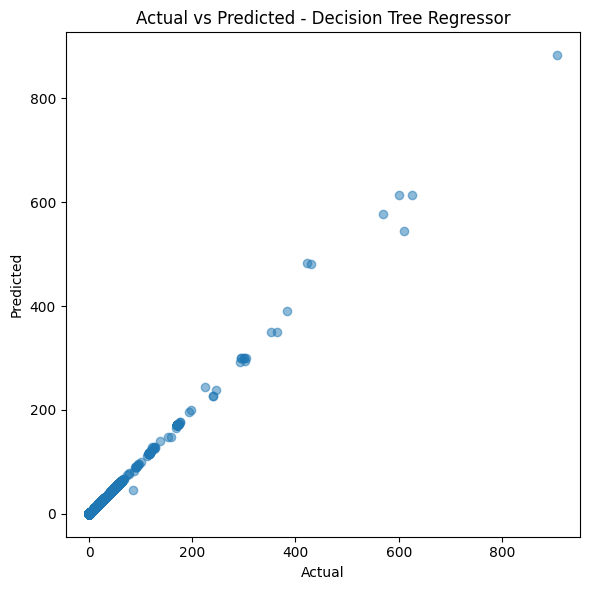

In [28]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("\nBest model:", best_model_name)

best_predictions = best_model.predict(X_test)

comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": best_predictions
})

comparison_df.to_csv(f"{output_dir}/actual_vs_predicted.csv", index=False)

print("Saved: actual_vs_predicted.csv")

print("\nSample actual vs predicted:")
print(comparison_df.head(20))

plt.figure(figsize=(6, 6))
plt.scatter(comparison_df["Actual"], comparison_df["Predicted"], alpha=0.5)
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.tight_layout()
plt.savefig(f"{output_dir}/actual_vs_predicted_plot.png")
plt.show()


Top 15 Random Forest important features:
                       Feature  Importance
43            num__fwd_iat.tot    0.944453
4       num__fwd_data_pkts_tot    0.017156
10    num__fwd_header_size_tot    0.004708
6        num__fwd_pkts_per_sec    0.004085
45            num__fwd_iat.std    0.003732
3            num__bwd_pkts_tot    0.002811
44            num__fwd_iat.avg    0.002776
2            num__fwd_pkts_tot    0.002726
41            num__fwd_iat.min    0.001784
20     num__bwd_PSH_flag_count    0.001769
12    num__fwd_header_size_max    0.001425
38  num__flow_pkts_payload.tot    0.001337
28   num__fwd_pkts_payload.tot    0.001231
33   num__bwd_pkts_payload.tot    0.001138
39  num__flow_pkts_payload.avg    0.001091


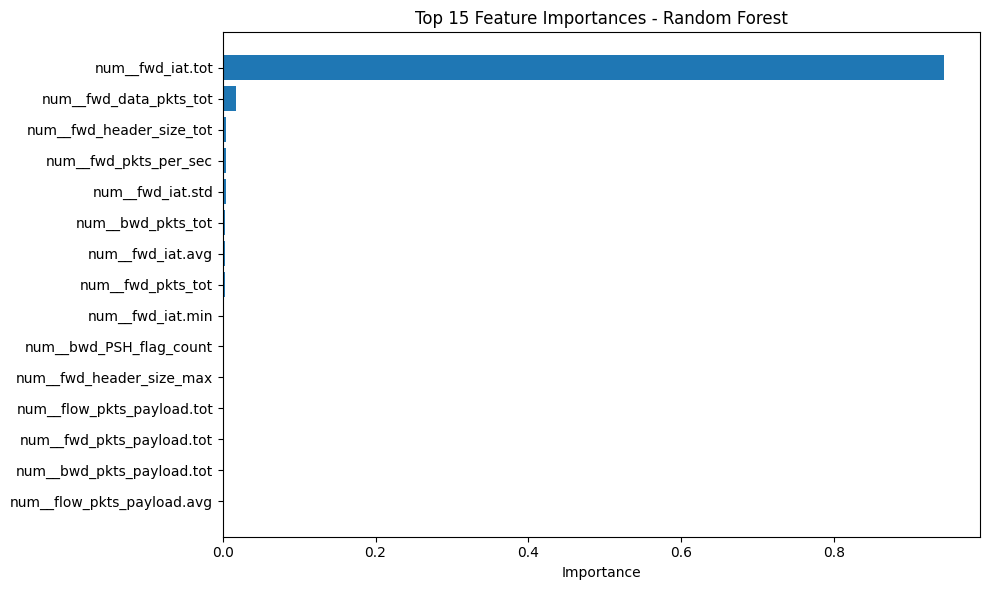

In [29]:
if "Random Forest Regressor" in trained_models:
    rf_pipeline = trained_models["Random Forest Regressor"]
    rf_model = rf_pipeline.named_steps["model"]
    rf_preprocessor = rf_pipeline.named_steps["preprocessor"]

    feature_names = rf_preprocessor.get_feature_names_out()
    importances = rf_model.feature_importances_

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values(by="Importance", ascending=False)

    importance_df.to_csv(f"{output_dir}/random_forest_feature_importance.csv", index=False)

    print("\nTop 15 Random Forest important features:")
    print(importance_df.head(15))

    plt.figure(figsize=(10, 6))
    top15 = importance_df.head(15).sort_values(by="Importance")
    plt.barh(top15["Feature"], top15["Importance"])
    plt.title("Top 15 Feature Importances - Random Forest")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig(f"{output_dir}/random_forest_feature_importance.png")
    plt.show()

In [30]:
if "mae2" in globals() and "rmse2" in globals() and "r22" in globals():
    ablation_df = pd.DataFrame([{
        "Experiment": "Random Forest without fwd_iat.tot",
        "MAE": mae2,
        "RMSE": rmse2,
        "R2_Score": r22
    }])

    ablation_df.to_csv(f"{output_dir}/ablation_result_without_fwd_iat_tot.csv", index=False)
    print("\nSaved: ablation_result_without_fwd_iat_tot.csv")
    print(ablation_df)


Saved: ablation_result_without_fwd_iat_tot.csv
                          Experiment       MAE       RMSE  R2_Score
0  Random Forest without fwd_iat.tot  0.287798  12.456923  0.497216


In [31]:
print("\nAll files in final_outputs:")
print(os.listdir(output_dir))


All files in final_outputs:
['proto_counts.csv', 'log_target_distribution.png', 'top_correlated_features.png', 'random_forest_feature_importance.png', 'service_counts.csv', 'ablation_result_without_fwd_iat_tot.csv', 'random_forest_feature_importance.csv', 'service_distribution.png', 'model_results.csv', 'actual_vs_predicted.csv', 'model_comparison_r2.png', 'target_distribution.png', 'actual_vs_predicted_plot.png', 'top_correlations.csv', 'model_comparison_mae.png', 'protocol_distribution.png', 'model_comparison_rmse.png']
